**Practical 4 - Understanding Data with graphs**

Importing the required Python libraries. Pandas is used for data handling, NumPy for numerical operations, Matplotlib and Seaborn for creating graphs and visualizations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the TeachingRatings.csv dataset into a Pandas DataFrame named df.

In [ ]:
df = pd.read_csv('/content/TeachingRatings.csv')

Displays the first five rows of the dataset.

In [ ]:
print(df.head())

  minority  age  gender credits    beauty  eval division native tenure  \
0      yes   36  female    more  0.289916   4.3    upper    yes    yes   
1       no   59    male    more -0.737732   4.5    upper    yes    yes   
2       no   51    male    more -0.571984   3.7    upper    yes    yes   
3       no   40  female    more -0.677963   4.3    upper    yes    yes   
4       no   31  female    more  1.509794   4.4    upper    yes    yes   

   students  allstudents  prof  
0        24           43     1  
1        17           20     2  
2        55           55     3  
3        40           46     4  
4        42           48     5  


Displays the number of rows and columns in the dataset.

In [ ]:
print(df.shape)

(463, 12)


**Q-1**

In [ ]:
# Identify duplicate cases using 'prof'

duplicates = df[df.duplicated(subset='prof', keep=False)]

print("Duplicate cases:")
print(duplicates[['prof', 'age']].sort_values('prof'))

Duplicate cases:
     prof  age
0       1   36
94      1   36
95      1   36
96      1   36
97      2   59
..    ...  ...
455    93   32
93     94   42
461    94   42
460    94   42
462    94   42

[456 rows x 2 columns]


In [ ]:
# Average age using all observations
mean_age_all = df['age'].mean()

# Standard deviation using all observations
sd_age_all = df['age'].std()

print("Using all observations:")
print("Average age =", mean_age_all)
print("Standard deviation =", sd_age_all)

Using all observations:
Average age = 48.365010799136066
Standard deviation = 9.802742037864817


In [ ]:
# Keep only one observation for each instructor
df_unique = df.drop_duplicates(subset='prof', keep='first')

print("Number of observations after removing duplicates:",
      len(df_unique))

Number of observations after removing duplicates: 94


In [ ]:
mean_age_unique = df_unique['age'].mean()
sd_age_unique = df_unique['age'].std()

print("Using one observation per instructor:")
print("Average age =", mean_age_unique)
print("Standard deviation =", sd_age_unique)

Using one observation per instructor:
Average age = 47.5531914893617
Standard deviation = 10.256513295154951


**Q-2**

In [ ]:
# Check the values in division
print(df['division'].value_counts())


division
upper    306
lower    157
Name: count, dtype: int64


In [ ]:
# Calculate average teaching evaluation by division
avg_eval = df.groupby('division')['eval'].mean()

print("Average teaching evaluation by course division:")
print(avg_eval)

Average teaching evaluation by course division:
division
lower    4.087261
upper    3.952614
Name: eval, dtype: float64


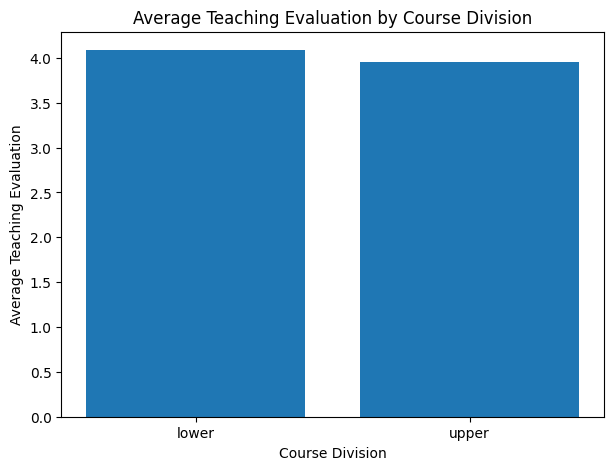

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(avg_eval.index, avg_eval.values)

plt.xlabel('Course Division')
plt.ylabel('Average Teaching Evaluation')
plt.title('Average Teaching Evaluation by Course Division')

plt.show()

**Q-3**

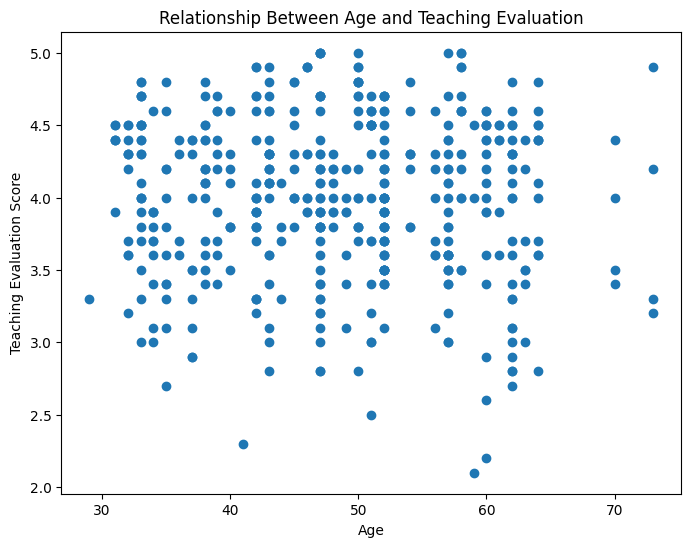

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df['age'], df['eval'])

plt.xlabel('Age')
plt.ylabel('Teaching Evaluation Score')
plt.title('Relationship Between Age and Teaching Evaluation')

plt.show()

**Q-4**

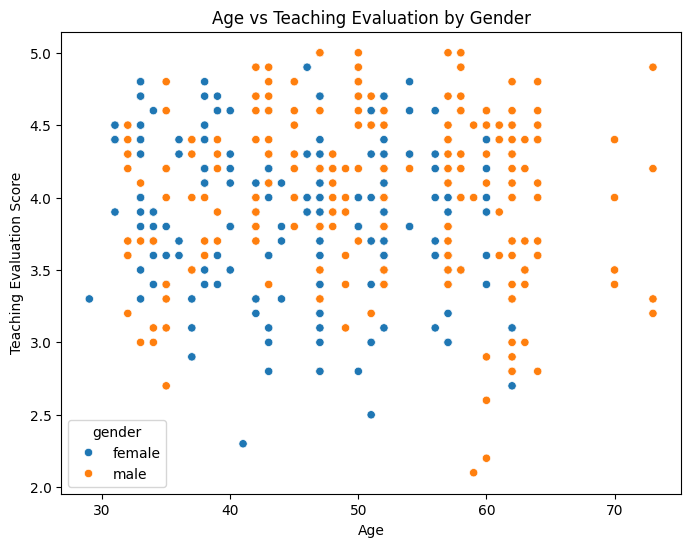

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='eval',
    hue='gender'
)

plt.xlabel('Age')
plt.ylabel('Teaching Evaluation Score')
plt.title('Age vs Teaching Evaluation by Gender')

plt.show()

**Q-5**

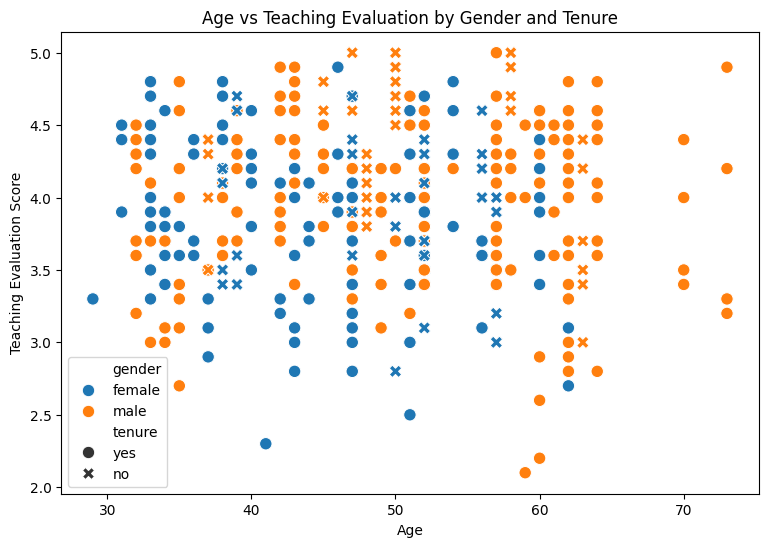

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='age',
    y='eval',
    hue='gender',
    style='tenure',
    s=80
)

plt.xlabel('Age')
plt.ylabel('Teaching Evaluation Score')
plt.title('Age vs Teaching Evaluation by Gender and Tenure')

plt.show()